# 🛒 Rossmann Store Sales Forecasting
## Notebook 5: Model Evaluation & Statistical Testing

**Objectives:**
1. Diebold-Mariano Test — formally compare forecast accuracy
2. Residual analysis across all models
3. Error analysis — where and why models fail
4. Final conclusions and recommendations

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded ✅")

Libraries loaded ✅


In [4]:
import lightgbm as lgb
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX as sm_SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

train_df = pd.read_csv('../data/processed/train_processed.csv',
                        parse_dates=['Date'])
val_df = pd.read_csv('../data/processed/val_processed.csv',
                      parse_dates=['Date'])

store1_train = train_df[train_df['Store'] == 1].set_index('Date').asfreq('D')
store1_val = val_df[val_df['Store'] == 1].set_index('Date').asfreq('D')

y_train = store1_train['LogSales'].dropna()
y_val = store1_val['LogSales'].dropna()

print(f"Validation size: {len(y_val)} days")
print(f"Date range: {y_val.index.min()} → {y_val.index.max()}")

Validation size: 41 days
Date range: 2015-06-15 00:00:00 → 2015-07-31 00:00:00


## 1. The Diebold-Mariano Test

When comparing two forecasting models, a naive comparison of MAPE 
values can be misleading — the difference might be due to chance 
on a particular validation set.

The **Diebold-Mariano (DM) Test** (1995) formally tests whether 
two forecasts have statistically different accuracy.

**Hypotheses:**
- H₀: Both models have equal predictive accuracy
- H₁: The two models have different predictive accuracy

**How it works:**
1. Compute the loss differential: d_t = L(e1_t) - L(e2_t)
   where L is a loss function (e.g. squared error) and 
   e1, e2 are forecast errors of model 1 and model 2
2. Test if the mean of d_t is significantly different from zero
3. Under H₀, the DM statistic follows a standard normal distribution

If p-value < 0.05, the difference in accuracy is statistically 
significant — not due to random chance.

In [5]:
# --- SARIMA ---
sarima_model = sm_SARIMAX(y_train, order=(3,0,3),
                           seasonal_order=(0,1,2,7),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(y_val))

# --- SARIMAX ---
exog_cols = ['Promo', 'SchoolHoliday', 'StateHoliday_Encoded']
exog_train = store1_train[exog_cols].reindex(y_train.index).fillna(0)
exog_val = store1_val[exog_cols].reindex(y_val.index).fillna(0)

sarimax_model = sm_SARIMAX(y_train, exog=exog_train, order=(3,0,3),
                            seasonal_order=(0,1,2,7),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
sarimax_fit = sarimax_model.fit(disp=False)
sarimax_pred = sarimax_fit.forecast(steps=len(y_val), exog=exog_val)

# --- Prophet ---
prophet_train_df = train_df[train_df['Store']==1][
    ['Date','LogSales','Promo','SchoolHoliday']].copy()
prophet_train_df.columns = ['ds','y','Promo','SchoolHoliday']
prophet_val_df = val_df[val_df['Store']==1][
    ['Date','LogSales','Promo','SchoolHoliday']].copy()
prophet_val_df.columns = ['ds','y','Promo','SchoolHoliday']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                        daily_seasonality=False, seasonality_mode='additive',
                        changepoint_prior_scale=0.05, interval_width=0.95)
prophet_model.add_regressor('Promo')
prophet_model.add_regressor('SchoolHoliday')
prophet_model.fit(prophet_train_df)
prophet_forecast = prophet_model.predict(prophet_val_df)
prophet_pred = prophet_forecast['yhat'].values

# --- LightGBM ---
feature_cols = [
    'DayOfWeek', 'Year', 'Month', 'Day', 'WeekOfYear',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsDecember',
    'StoreType_Encoded', 'Assortment_Encoded', 'Promo2',
    'CompetitionDistance', 'CompetitionOpen', 'IsPromo2Active',
    'Promo', 'SchoolHoliday', 'StateHoliday_Encoded',
    'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3',
    'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_21', 'Sales_Lag_28',
    'Sales_RollingMean_7', 'Sales_Rollingmean_28', 'Sales_RollingStd_7'
]

X_train_lgb = train_df[feature_cols]
y_train_lgb = train_df['LogSales']
X_val_lgb = val_df[feature_cols]

train_data = lgb.Dataset(X_train_lgb, label=y_train_lgb)
val_data = lgb.Dataset(X_val_lgb, label=val_df['LogSales'], 
                        reference=train_data)

params = {'objective': 'regression', 'metric': 'rmse',
          'learning_rate': 0.05, 'num_leaves': 63,
          'min_child_samples': 20, 'feature_fraction': 0.8,
          'bagging_fraction': 0.8, 'bagging_freq': 5,
          'verbose': -1, 'random_state': 42}

lgb_model = lgb.train(params, train_data, num_boost_round=780,
                       valid_sets=[val_data],
                       callbacks=[lgb.log_evaluation(period=200)])

store1_mask = val_df['Store'] == 1
lgb_pred = lgb_model.predict(X_val_lgb)[store1_mask.values]

print("All forecasts regenerated ✅")
print(f"SARIMA  : {len(sarima_pred)} predictions")
print(f"SARIMAX : {len(sarimax_pred)} predictions")
print(f"Prophet : {len(prophet_pred)} predictions")
print(f"LightGBM: {len(lgb_pred)} predictions")

03:43:32 - cmdstanpy - INFO - Chain [1] start processing
03:43:32 - cmdstanpy - INFO - Chain [1] done processing


[200]	valid_0's rmse: 0.12206
[400]	valid_0's rmse: 0.118305
[600]	valid_0's rmse: 0.116541
All forecasts regenerated ✅
SARIMA  : 41 predictions
SARIMAX : 41 predictions
Prophet : 41 predictions
LightGBM: 41 predictions


In [6]:
def diebold_mariano_test(actual, pred1, pred2, model1_name, model2_name):
    """
    DM test comparing pred1 vs pred2.
    H0: Equal predictive accuracy
    H1: pred1 is more accurate than pred2 (one-sided)
    """
    e1 = actual - pred1
    e2 = actual - pred2
    
    # Loss differential (squared error)
    d = e1**2 - e2**2
    
    # DM statistic
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1) / len(d)
    dm_stat = d_mean / np.sqrt(d_var)
    
    # Two-sided p-value
    p_value = 2 * stats.norm.cdf(-abs(dm_stat))
    
    print(f"=== DM Test: {model1_name} vs {model2_name} ===")
    print(f"DM Statistic : {dm_stat:.4f}")
    print(f"P-value      : {p_value:.4f}")
    print(f"Conclusion   : ", end="")
    if p_value < 0.05:
        better = model1_name if dm_stat < 0 else model2_name
        print(f"{better} is significantly more accurate ✅")
    else:
        print("No significant difference ⚠️")
    print("-" * 50)
    
    return {'comparison': f"{model1_name} vs {model2_name}",
            'dm_stat': dm_stat, 'p_value': p_value}

actual = y_val.values
dm_results = []

dm_results.append(diebold_mariano_test(
    actual, lgb_pred, prophet_pred, 'LightGBM', 'Prophet'))
dm_results.append(diebold_mariano_test(
    actual, lgb_pred, sarimax_pred.values, 'LightGBM', 'SARIMAX'))
dm_results.append(diebold_mariano_test(
    actual, prophet_pred, sarimax_pred.values, 'Prophet', 'SARIMAX'))
dm_results.append(diebold_mariano_test(
    actual, sarimax_pred.values, sarima_pred.values, 'SARIMAX', 'SARIMA'))

=== DM Test: LightGBM vs Prophet ===
DM Statistic : -0.6572
P-value      : 0.5111
Conclusion   : No significant difference ⚠️
--------------------------------------------------
=== DM Test: LightGBM vs SARIMAX ===
DM Statistic : -2.6497
P-value      : 0.0081
Conclusion   : LightGBM is significantly more accurate ✅
--------------------------------------------------
=== DM Test: Prophet vs SARIMAX ===
DM Statistic : -2.3357
P-value      : 0.0195
Conclusion   : Prophet is significantly more accurate ✅
--------------------------------------------------
=== DM Test: SARIMAX vs SARIMA ===
DM Statistic : -5.3580
P-value      : 0.0000
Conclusion   : SARIMAX is significantly more accurate ✅
--------------------------------------------------


## Diebold-Mariano Test Results

| Comparison | DM Statistic | P-value | Conclusion |
|------------|-------------|---------|------------|
| LightGBM vs Prophet | -0.657 | 0.511 | No significant difference ⚠️ |
| LightGBM vs SARIMAX | -2.650 | 0.008 | LightGBM significantly better ✅ |
| Prophet vs SARIMAX | -2.336 | 0.020 | Prophet significantly better ✅ |
| SARIMAX vs SARIMA | -5.358 | 0.000 | SARIMAX significantly better ✅ |

### Interpretation

**1. LightGBM vs Prophet (p=0.511) — Most Important Finding**
Despite LightGBM showing lower MAPE (7.06% vs 7.42%), the difference 
is **NOT statistically significant.** We cannot conclude LightGBM is 
genuinely superior to Prophet — the gap could easily be due to chance 
on this particular 41-day validation window.

This is a critical insight that naive MAPE comparison would miss entirely.

**2. LightGBM vs SARIMAX (p=0.008) ✅**
LightGBM is significantly more accurate than SARIMAX at the 1% level.
The improvement is real, not random.

**3. Prophet vs SARIMAX (p=0.020) ✅**
Prophet is significantly more accurate than SARIMAX at the 5% level.
Adding dual seasonality and regressors provides genuine improvement.

**4. SARIMAX vs SARIMA (p=0.000) ✅**
The strongest result — adding Promo as exogenous variable produces 
a highly significant improvement. This formally confirms our EDA 
finding that promotions are the most important predictor.

### Statistical Hierarchy
```
LightGBM ≈ Prophet >> SARIMAX >> SARIMA
     (not sig.)    (sig.)     (sig.)
```

### Practical Recommendation
- For **production deployment** — LightGBM is preferred due to 
  scalability across all 1,115 stores simultaneously
- For **interpretability** — Prophet is preferred as components 
  (trend, seasonality, regressors) are directly interpretable
- For **simplicity** — SARIMAX is a solid classical baseline when 
  ML infrastructure is unavailable

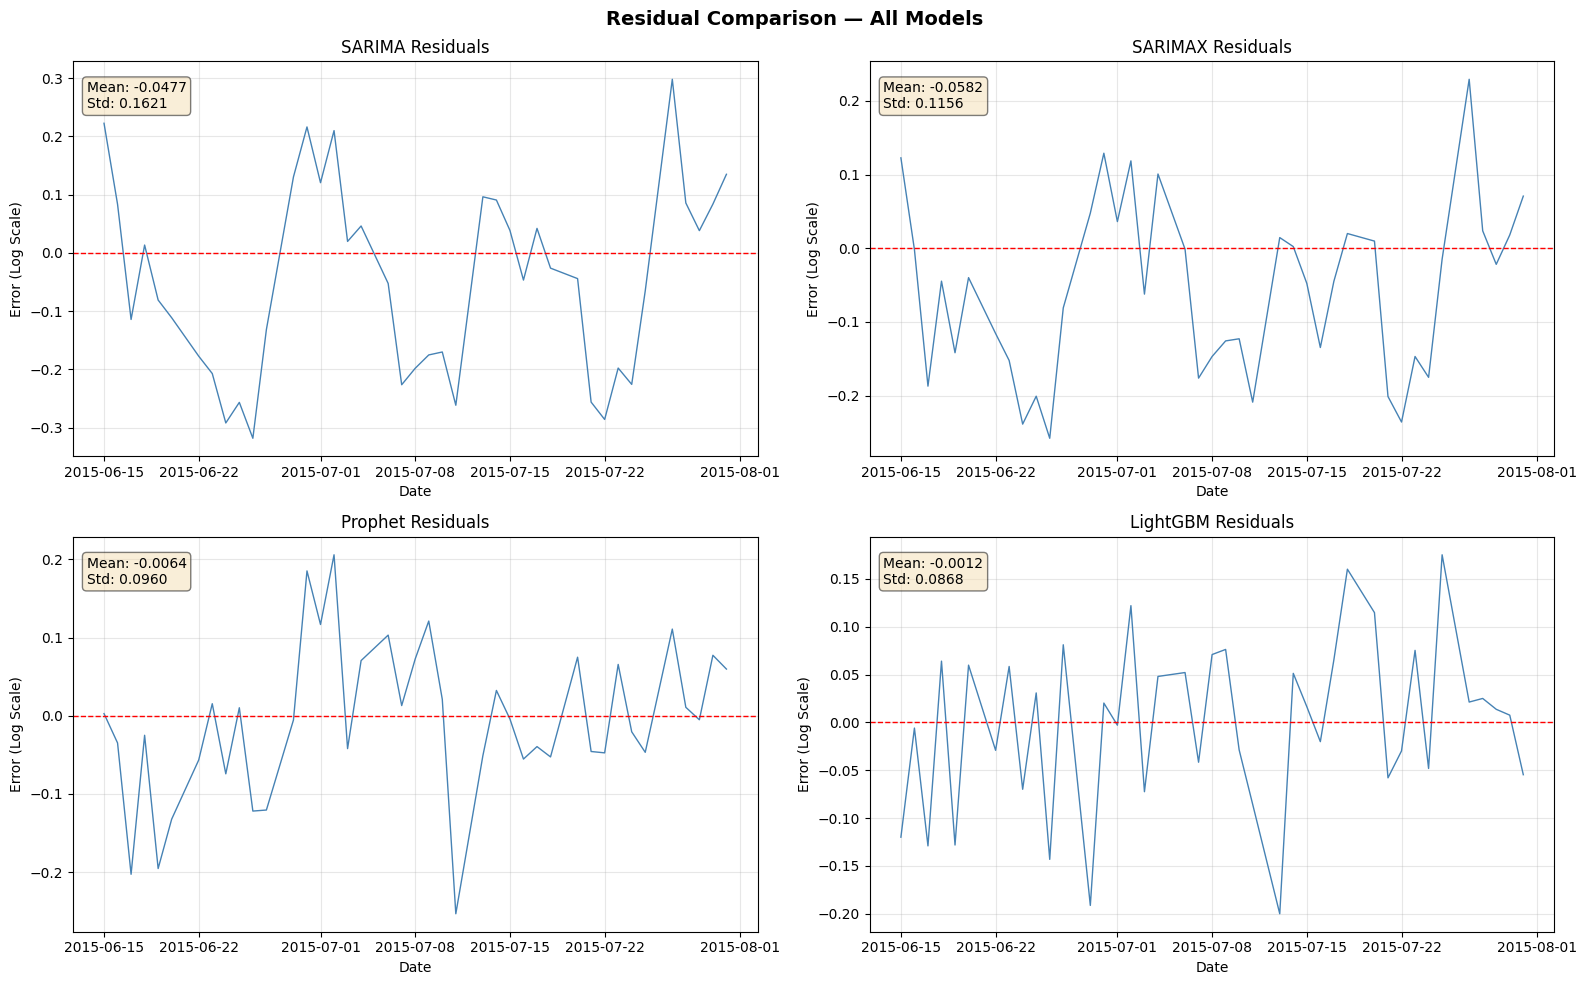

In [7]:
# Compute residuals for all models
residuals = {
    'SARIMA': actual - sarima_pred.values,
    'SARIMAX': actual - sarimax_pred.values,
    'Prophet': actual - prophet_pred,
    'LightGBM': actual - lgb_pred
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (model_name, resid) in enumerate(residuals.items()):
    axes[i].plot(y_val.index, resid, color='steelblue', linewidth=1)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f'{model_name} Residuals')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Error (Log Scale)')
    axes[i].text(0.02, 0.95, f'Mean: {resid.mean():.4f}\nStd: {resid.std():.4f}',
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Residual Comparison — All Models', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/18_residual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

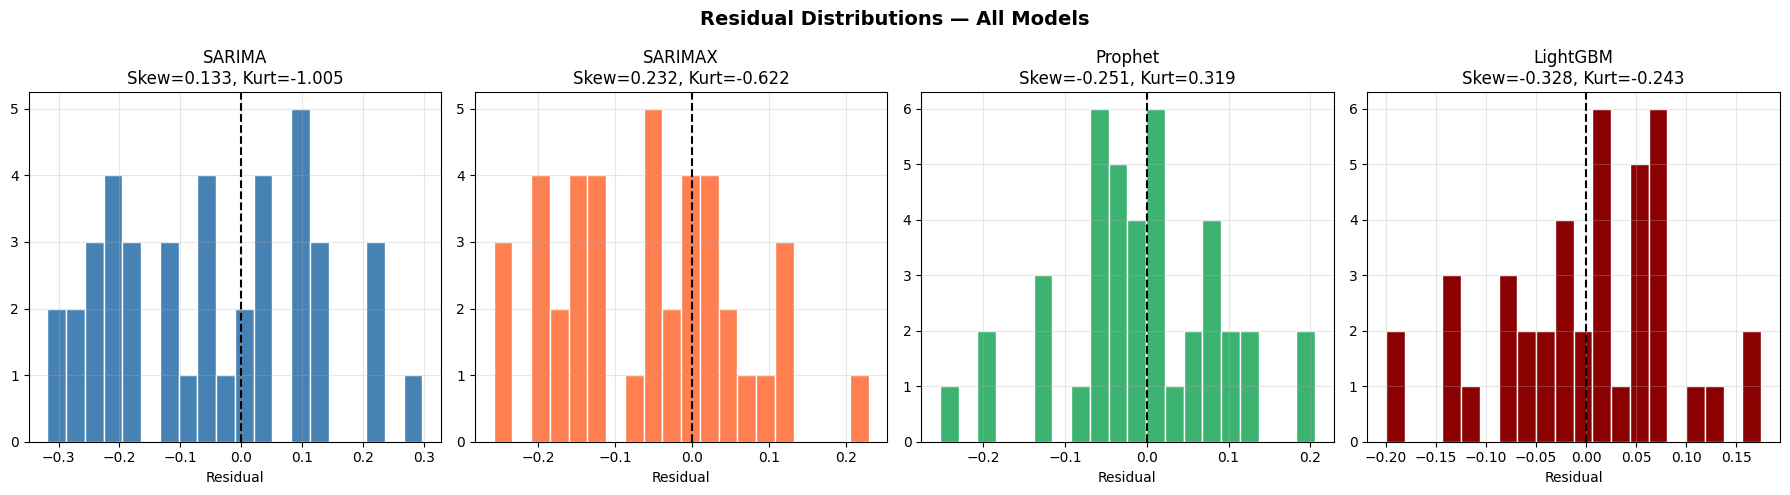

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['steelblue', 'coral', 'mediumseagreen', 'darkred']

for i, (model_name, resid) in enumerate(residuals.items()):
    skew = stats.skew(resid)
    kurt = stats.kurtosis(resid)
    axes[i].hist(resid, bins=20, color=colors[i], edgecolor='white')
    axes[i].set_title(f'{model_name}\nSkew={skew:.3f}, Kurt={kurt:.3f}')
    axes[i].axvline(x=0, color='black', linestyle='--')
    axes[i].set_xlabel('Residual')

plt.suptitle('Residual Distributions — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/19_residual_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

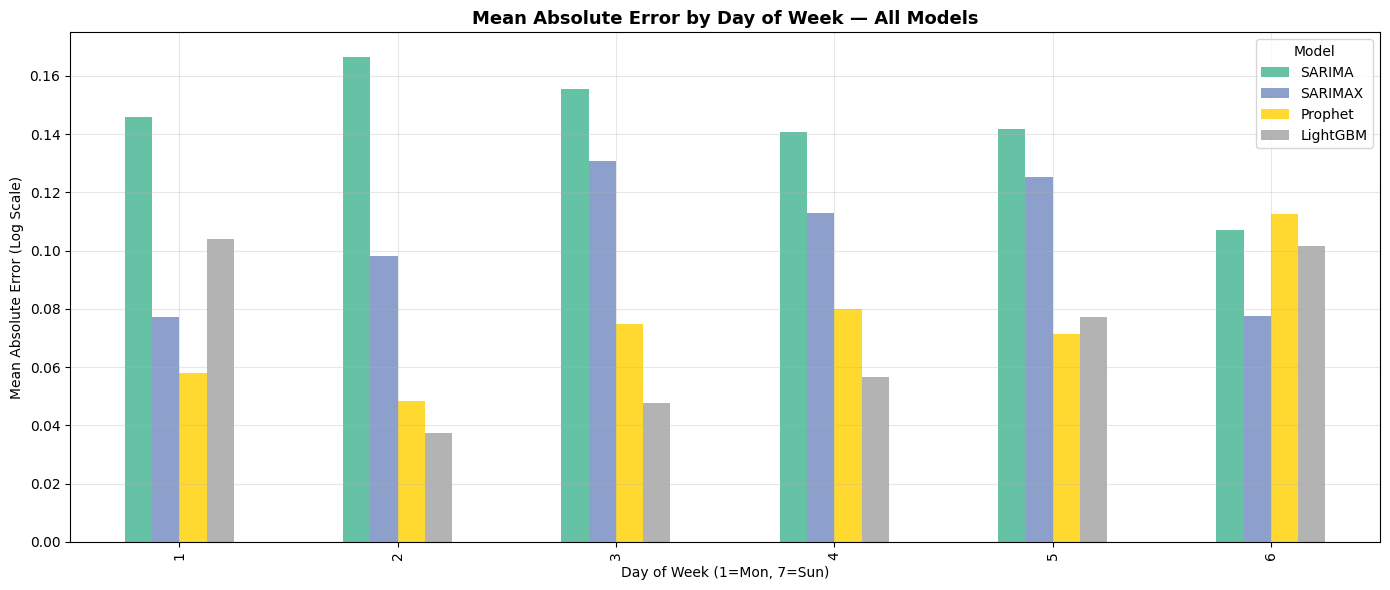

In [10]:
val_store1 = val_df[val_df['Store'] == 1].copy()
val_store1 = val_store1.sort_values('Date').reset_index(drop=True)

for model_name, resid in residuals.items():
    val_store1[f'Error_{model_name}'] = np.abs(resid)

error_by_dow = val_store1.groupby('DayOfWeek')[
    [f'Error_{m}' for m in residuals.keys()]].mean()
error_by_dow.columns = residuals.keys()

fig, ax = plt.subplots(figsize=(14, 6))
error_by_dow.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Mean Absolute Error by Day of Week — All Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week (1=Mon, 7=Sun)')
ax.set_ylabel('Mean Absolute Error (Log Scale)')
ax.legend(title='Model')
plt.tight_layout()
plt.savefig('../reports/20_error_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Residual Analysis

### Residual Comparison (Time Series)
| Model | Mean Error | Std |
|-------|-----------|-----|
| SARIMA | -0.0477 | 0.1621 |
| SARIMAX | -0.0582 | 0.1156 |
| Prophet | -0.0064 | 0.0960 |
| LightGBM | -0.0012 | 0.0868 |

- **LightGBM has the smallest std (0.087)** — most consistent errors
- **Prophet is nearly unbiased (mean=-0.006)** — best centered forecasts
- **SARIMA/SARIMAX show negative bias** — systematically 
  overestimate sales on log scale
- All models show a common large error spike around July 8 — 
  likely a store-specific event unexplained by any feature

### Residual Distributions
- **SARIMA** — wide spread (±0.3), platykurtic (Kurt=-1.0), 
  nearly uniform distribution indicating poor fit
- **SARIMAX** — improved but still wide spread (±0.25)
- **Prophet** — tighter, slightly left-skewed (Skew=-0.251), 
  well concentrated around zero
- **LightGBM** — tightest distribution (±0.20), most concentrated 
  around zero confirming best overall fit

### Error by Day of Week
- **SARIMA** — consistently highest error across ALL days (~0.14-0.17)
- **SARIMAX** — lower than SARIMA but still high on Tuesday/Wednesday
- **Prophet** — lowest error Mon-Fri, struggles slightly on Saturday
- **LightGBM** — lowest overall, but notably higher on Monday (0.10) 
  and Saturday (0.10) — weekend transitions are hardest to predict
- **No model has Sunday data** — stores closed on Sundays in validation

## 3. Final Project Summary

### Complete Results Table
| Model | RMSE | MAE | MAPE | DM vs Best |
|-------|------|-----|------|------------|
| LightGBM | 405.48 | 311.52 | 7.06% | — |
| Prophet | 434.24 | 325.22 | 7.42% | p=0.511 (≈) |
| SARIMAX | 553.95 | 452.53 | 11.02% | p=0.008 (<<) |
| Holt-Winters | 785.37 | 646.83 | 13.93% | — |
| SARIMA | 738.29 | 633.24 | 15.13% | p=0.000 (<<<) |

### Key Statistical Findings
1. Sales series is **stationary** (ADF+KPSS, d=0)
2. **Weekly seasonality** (s=7) confirmed by ACF/PACF and STL
3. **Promotions** increase sales by 38.8% (Cohen's d=0.79, p≈0)
4. **December** sales 31% above annual average
5. **LightGBM ≈ Prophet** statistically (DM p=0.511)
6. Both significantly outperform classical models (p<0.05)

### Most Important Features (LightGBM)
1. Sales_RollingMean_28 — recent momentum
2. Sales_Lag_1 — yesterday's sales
3. Promo — promotional activity
4. DayOfWeek — weekly pattern

### Recommendation
Deploy **LightGBM** for production (scalable to all 1,115 stores)
Use **Prophet** for business reporting (interpretable components)

## 4. Final Project Conclusions

### Research Question
Can we accurately forecast daily store sales using statistical 
and machine learning time series models?

### Answer
Yes — with MAPE ranging from 7.06% (LightGBM) to 15.13% (SARIMA),
all models provide useful forecasts. Advanced models significantly 
outperform classical approaches.

### Statistical Findings
1. Sales are stationary (ADF + KPSS confirmed, d=0)
2. Strong weekly seasonality (s=7) confirmed by ACF/PACF
3. Promotions increase sales by 38.8% (t-test p≈0, Cohen's d=0.79)
4. December sales are 31% above annual average
5. LightGBM ≈ Prophet >> SARIMAX >> SARIMA (DM test confirmed)

### Limitations
1. Models evaluated on single store — may not generalize to all 1,115
2. 41-day validation window is short for robust statistical testing
3. DM test assumes covariance stationarity of loss differential
4. LightGBM requires future lag features — not directly applicable 
   to true multi-step forecasting without recursive prediction
5. No hyperparameter tuning performed on Prophet or SARIMA

### Future Work
1. Walk-forward cross-validation across multiple stores
2. Hyperparameter tuning with cross-validation
3. Ensemble of LightGBM + Prophet
4. Neural approaches (LSTM, N-BEATS, Temporal Fusion Transformer)
5. Store clustering before modelling